rhs_all shape: (10000, 128, 128)
sol_all shape: (10000, 128, 128)
Using device: cuda
Training sizes: [50, 100, 200, 500, 1000, 2000, 4000, 8000, 8100]

Training with n_train = 50

--- Vanilla DeepONet | n_train = 50 ---
[   1/500] train MSE: 9.940826e-01 | val relL2: 1.599588e+00 | best: 1.599588e+00
[  50/500] train MSE: 2.024069e-01 | val relL2: 5.664480e-01 | best: 5.389016e-01
[ 100/500] train MSE: 5.906138e-02 | val relL2: 3.653937e-01 | best: 3.605932e-01
[ 150/500] train MSE: 4.053685e-02 | val relL2: 3.225399e-01 | best: 3.059678e-01
[ 200/500] train MSE: 1.993786e-02 | val relL2: 2.628423e-01 | best: 2.628423e-01
[ 250/500] train MSE: 1.726852e-02 | val relL2: 2.583237e-01 | best: 2.574234e-01
[ 300/500] train MSE: 1.953746e-02 | val relL2: 2.554506e-01 | best: 2.455672e-01
[ 350/500] train MSE: 9.333812e-03 | val relL2: 2.406270e-01 | best: 2.394363e-01
[ 400/500] train MSE: 1.442179e-02 | val relL2: 2.617919e-01 | best: 2.385511e-01
[ 450/500] train MSE: 1.118478e-02 | val r

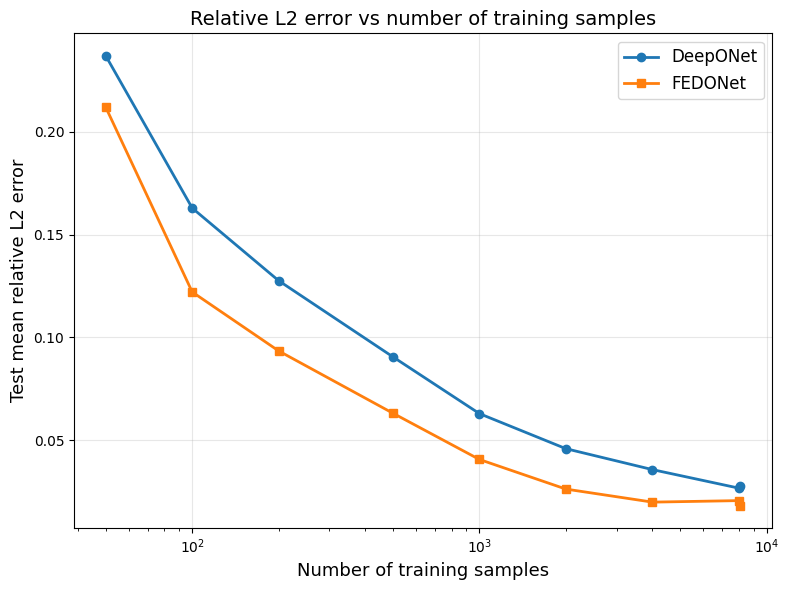


Saved figure: relL2_vs_training_samples_poisson.png


In [1]:
# =============================== Poisson DeepONet / FEDONet ===============================
# Effect of training sample size on test relative L2 error
#
# Compares:
#   (1) Vanilla DeepONet
#   (2) Fourier-Embedded DeepONet (FEDONet)
#
# Fixed validation/test split, varying training subset sizes.
# =========================================================================================

import os
import random
import math
import copy
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split

# ------------------------------- Reproducibility -------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --------------------------------- Utilities ----------------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rel_l2(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-12):
    """
    Relative L2 per-sample: ||a-b||_2 / (||b||_2 + eps)
    Accepts tensors shaped [B, 1, H, W] or [B, H, W].
    Returns tensor of shape [B].
    """
    if a.dim() == 4:
        a = a.view(a.size(0), -1)
        b = b.view(b.size(0), -1)
    elif a.dim() == 3:
        a = a.view(a.size(0), -1)
        b = b.view(b.size(0), -1)
    num = torch.norm(a - b, dim=1)
    den = torch.norm(b, dim=1) + eps
    return num / den

@torch.no_grad()
def evaluate_loader_rel_l2(model, loader, device, coords):
    model.eval()
    total_rel, count = 0.0, 0
    coords = coords.to(device)

    for f_batch, u_batch in loader:
        f_batch = f_batch.to(device)
        u_batch = u_batch.to(device)
        preds = model(f_batch, coords)
        r = rel_l2(preds, u_batch)
        total_rel += r.sum().item()
        count += r.numel()

    return total_rel / max(count, 1)

# --------------------------------- Dataset ------------------------------------
class PoissonDataset(Dataset):
    """
    Stores pairs (rhs_f, sol_u) with shapes [N, H, W] each.
    Provides tensors [N, 1, H, W] and a static coord grid [H, W, 2] in [0,1]^2.
    """
    def __init__(self, rhs_f, sol_u):
        assert rhs_f.shape == sol_u.shape, "rhs_f and sol_u must have same shape"
        self.rhs_f = torch.tensor(rhs_f, dtype=torch.float32).unsqueeze(1)  # [N,1,H,W]
        self.sol_u = torch.tensor(sol_u, dtype=torch.float32).unsqueeze(1)  # [N,1,H,W]

        H, W = self.rhs_f.shape[-2:]
        grid_x = np.linspace(0.0, 1.0, W, dtype=np.float32)
        grid_y = np.linspace(0.0, 1.0, H, dtype=np.float32)
        X, Y = np.meshgrid(grid_x, grid_y)
        coords = np.stack([X, Y], axis=-1)  # [H,W,2]
        self.coords = torch.tensor(coords, dtype=torch.float32)

    def __len__(self):
        return self.rhs_f.shape[0]

    def __getitem__(self, idx):
        return self.rhs_f[idx], self.sol_u[idx]

# --------------------------------- Models -------------------------------------
class BranchNet(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool2d((16, 16)),
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128), nn.ReLU(),
            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class TrunkNetVanilla(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            # nn.Linear(128, 128), nn.ReLU(),
            # nn.Linear(128, 128), nn.ReLU(),
            # nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, out_dim), nn.ReLU(),
        )

    def forward(self, coords_flat):
        return self.mlp(coords_flat)

class FourierEmbedding(nn.Module):
    def __init__(self, input_dim=2, mapping_size=256, sigma=10.0):
        super().__init__()
        B = torch.randn(input_dim, mapping_size) * sigma
        self.register_buffer("B", B)

    def forward(self, x):
        x_proj = 2.0 * math.pi * (x @ self.B)
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class TrunkNetFourier(nn.Module):
    def __init__(self, out_dim=128, mapping_size=256, sigma=10.0):
        super().__init__()
        self.embed = FourierEmbedding(input_dim=2, mapping_size=mapping_size, sigma=sigma)
        in_dim = 2 * mapping_size
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            # nn.Linear(256, 256), nn.ReLU(),
            # nn.Linear(256, 256), nn.ReLU(),
            # nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(128, out_dim), nn.ReLU(),
        )

    def forward(self, coords_flat):
        z = self.embed(coords_flat)
        return self.mlp(z)

class DeepONet(nn.Module):
    def __init__(self, branch: nn.Module, trunk: nn.Module):
        super().__init__()
        self.branch = branch
        self.trunk = trunk

    def forward(self, f_batch, coords):
        """
        f_batch: [B,1,H,W]
        coords : [H,W,2]
        returns: [B,1,H,W]
        """
        B, _, H, W = f_batch.shape
        coords_flat = coords.view(-1, 2)              # [H*W, 2]
        trunk_out = self.trunk(coords_flat)           # [H*W, D]
        branch_out = self.branch(f_batch)             # [B, D]
        out = torch.matmul(branch_out, trunk_out.t()) # [B, H*W]
        out = out.view(B, 1, H, W)
        return out

# ----------------------------- Training / Checkpoint ---------------------------
def train_model(
    model,
    train_loader,
    val_loader,
    device,
    coords,
    num_epochs=300,
    lr=1e-3,
    print_every=50
):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_state = None
    best_val_rel_l2 = float("inf")
    coords = coords.to(device)

    history = {"train_mse": [], "val_rel_l2": []}

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss_sum, train_count = 0.0, 0

        for f_batch, u_batch in train_loader:
            f_batch = f_batch.to(device)
            u_batch = u_batch.to(device)

            optimizer.zero_grad()
            preds = model(f_batch, coords)
            loss = criterion(preds, u_batch)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * u_batch.numel()
            train_count += u_batch.numel()

        train_mse = train_loss_sum / max(train_count, 1)
        val_rel = evaluate_loader_rel_l2(model, val_loader, device, coords)

        history["train_mse"].append(train_mse)
        history["val_rel_l2"].append(val_rel)

        if val_rel < best_val_rel_l2:
            best_val_rel_l2 = val_rel
            best_state = copy.deepcopy(model.state_dict())

        if (epoch % print_every) == 0 or epoch == 1 or epoch == num_epochs:
            print(f"[{epoch:4d}/{num_epochs}] "
                  f"train MSE: {train_mse:.6e} | val relL2: {val_rel:.6e} | best: {best_val_rel_l2:.6e}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_rel_l2

# ----------------------------- Main Experiment --------------------------------
if __name__ == "__main__":
    # ------------------------- Load data (.mat) -------------------------
    data = scipy.io.loadmat("poisson_1.mat")
    rhs_all = data["f_data"].astype(np.float32)    # [N,H,W]
    sol_all = data["phi_data"].astype(np.float32)  # [N,H,W]

    print("rhs_all shape:", rhs_all.shape)
    print("sol_all shape:", sol_all.shape)

    # ------------------ Train/Val/Test split (fixed once) ------------------
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        rhs_all, sol_all, test_size=0.10, random_state=SEED, shuffle=True
    )

    X_train_base, X_val, y_train_base, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.10, random_state=SEED, shuffle=True
    )

    # ------------------------ Normalize using full base train only ------------------------
    f_mean, f_std = X_train_base.mean(), X_train_base.std()
    u_mean, u_std = y_train_base.mean(), y_train_base.std()

    def norm_f(x): return (x - f_mean) / (f_std + 1e-12)
    def norm_u(x): return (x - u_mean) / (u_std + 1e-12)

    X_train_base = norm_f(X_train_base)
    X_val = norm_f(X_val)
    X_test = norm_f(X_test)

    y_train_base = norm_u(y_train_base)
    y_val = norm_u(y_val)
    y_test = norm_u(y_test)

    # ------------------------- Full datasets -------------------------
    full_train_ds = PoissonDataset(rhs_f=X_train_base, sol_u=y_train_base)
    val_ds = PoissonDataset(rhs_f=X_val, sol_u=y_val)
    test_ds = PoissonDataset(rhs_f=X_test, sol_u=y_test)

    coords = full_train_ds.coords
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # -------------------- Training sample sizes to test --------------------
    max_train = len(full_train_ds)
    candidate_sizes = [50, 100, 200, 500, 1000, 2000, 4000, 8000, max_train]
    train_sizes = [n for n in candidate_sizes if n <= max_train]

    if train_sizes[-1] != max_train:
        train_sizes.append(max_train)

    print("Training sizes:", train_sizes)

    # -------------------- Common loader settings --------------------
    BATCH_SIZE = 256
    VAL_BATCH_SIZE = 256
    TEST_BATCH_SIZE = 256
    NUM_EPOCHS_DON = 500
    NUM_EPOCHS_FED = 500
    LR = 1e-3

    # -------------------- Store results --------------------
    test_rel_v_list = []
    test_rel_f_list = []

    # fixed permutation so nesting is consistent across sample sizes
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(full_train_ds))

    # -------------------- Loop over train sizes --------------------
    for n_train in train_sizes:
        print("\n" + "=" * 90)
        print(f"Training with n_train = {n_train}")
        print("=" * 90)

        subset_idx = perm[:n_train]
        train_subset = Subset(full_train_ds, subset_idx.tolist())

        train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds, batch_size=VAL_BATCH_SIZE, shuffle=False, drop_last=False)
        test_loader  = DataLoader(test_ds, batch_size=TEST_BATCH_SIZE, shuffle=False, drop_last=False)

        # -------------------- Vanilla DeepONet --------------------
        print(f"\n--- Vanilla DeepONet | n_train = {n_train} ---")
        set_seed(SEED)

        model_v = DeepONet(
            branch=BranchNet(out_dim=128),
            trunk=TrunkNetVanilla(out_dim=128)
        ).to(device)

        model_v, hist_v, best_val_rel_v = train_model(
            model=model_v,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            coords=coords,
            num_epochs=NUM_EPOCHS_DON,
            lr=LR,
            print_every=50
        )

        test_rel_v = evaluate_loader_rel_l2(model_v, test_loader, device, coords)
        test_rel_v_list.append(test_rel_v)

        print(f"[Vanilla DeepONet] n_train={n_train} | best val relL2={best_val_rel_v:.6e} | test relL2={test_rel_v:.6e}")

        # -------------------- FEDONet --------------------
        print(f"\n--- FEDONet | n_train = {n_train} ---")
        set_seed(SEED)

        model_f = DeepONet(
            branch=BranchNet(out_dim=128),
            trunk=TrunkNetFourier(out_dim=128, mapping_size=256, sigma=10.0)
        ).to(device)

        model_f, hist_f, best_val_rel_f = train_model(
            model=model_f,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            coords=coords,
            num_epochs=NUM_EPOCHS_FED,
            lr=LR,
            print_every=50
        )

        test_rel_f = evaluate_loader_rel_l2(model_f, test_loader, device, coords)
        test_rel_f_list.append(test_rel_f)

        print(f"[FEDONet] n_train={n_train} | best val relL2={best_val_rel_f:.6e} | test relL2={test_rel_f:.6e}")

    # -------------------- Convert to arrays --------------------
    train_sizes = np.array(train_sizes, dtype=int)
    test_rel_v_list = np.array(test_rel_v_list, dtype=np.float64)
    test_rel_f_list = np.array(test_rel_f_list, dtype=np.float64)

    # -------------------- Print summary table --------------------
    print("\n" + "=" * 90)
    print("FINAL SUMMARY: Test mean relative L2 vs number of training samples")
    print("=" * 90)
    for n, rv, rf in zip(train_sizes, test_rel_v_list, test_rel_f_list):
        print(f"n_train = {n:6d} | DeepONet = {rv:.6e} | FEDONet = {rf:.6e}")

    # -------------------- Plot --------------------
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, test_rel_v_list, marker='o', linewidth=2, label='DeepONet')
    plt.plot(train_sizes, test_rel_f_list, marker='s', linewidth=2, label='FEDONet')
    plt.xlabel('Number of training samples', fontsize=13)
    plt.ylabel('Test mean relative L2 error', fontsize=13)
    plt.title('Relative L2 error vs number of training samples', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.xscale('log')
    plt.tight_layout()
    plt.show()

    # -------------------- Optional saved figure --------------------
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, test_rel_v_list, marker='o', linewidth=2, label='DeepONet')
    plt.plot(train_sizes, test_rel_f_list, marker='s', linewidth=2, label='FEDONet')
    plt.xlabel('Number of training samples', fontsize=13)
    plt.ylabel('Test mean relative L2 error', fontsize=13)
    plt.title('Relative L2 error vs training sample size', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.xscale('log')
    plt.tight_layout()
    plt.savefig('relL2_vs_training_samples_poisson.png', dpi=300)
    plt.close()

    print("\nSaved figure: relL2_vs_training_samples_poisson.png")

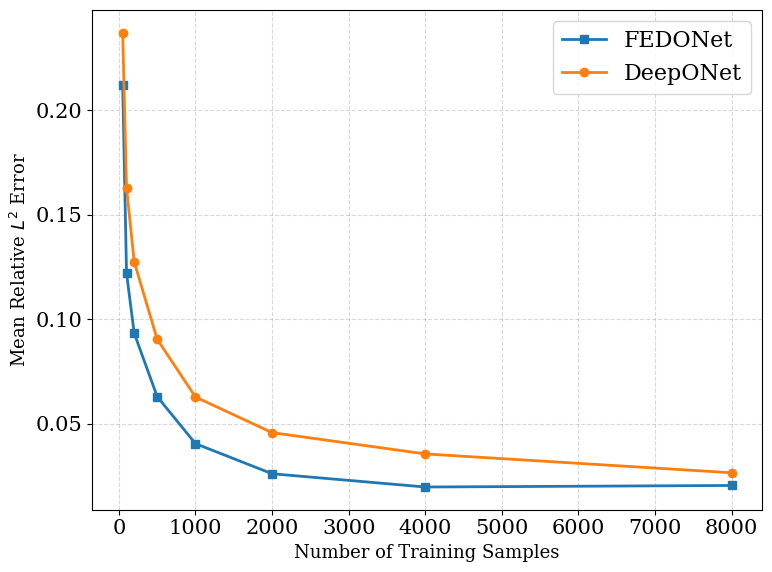

In [2]:
import matplotlib as mpl


def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})


plt.figure(figsize=(8, 6))
plt.plot(train_sizes[:-1], test_rel_f_list[:-1], marker='s', linewidth=2, label='FEDONet')
plt.plot(train_sizes[:-1], test_rel_v_list[:-1], marker='o', linewidth=2, label='DeepONet')
# plt.yscale('log')
plt.xlabel('Number of Training Samples', fontsize=13)
plt.ylabel('Mean Relative $L^2$ Error', fontsize=13)
# plt.title('Relative L2 error vs number of training samples', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
# plt.xscale('log')
plt.tight_layout()
plt.show()

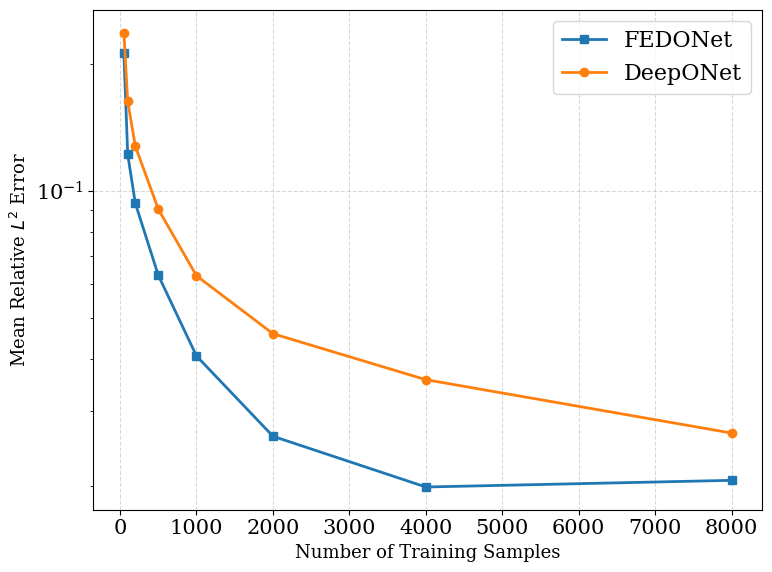

In [3]:
import matplotlib as mpl


def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})


plt.figure(figsize=(8, 6))
plt.plot(train_sizes[:-1], test_rel_f_list[:-1], marker='s', linewidth=2, label='FEDONet')
plt.plot(train_sizes[:-1], test_rel_v_list[:-1], marker='o', linewidth=2, label='DeepONet')
plt.yscale('log')
plt.xlabel('Number of Training Samples', fontsize=13)
plt.ylabel('Mean Relative $L^2$ Error', fontsize=13)
# plt.title('Relative L2 error vs number of training samples', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
# plt.xscale('log')
plt.tight_layout()
plt.show()